# **Monthly Viz Program for Political Issues**

# **Install and Importing Library**

## **Data Access and Manipulation**

In [31]:
import pandas as pd; import matplotlib.pyplot as plt; 
import matplotlib.colors as mcolors; import matplotlib.dates as mdates
import numpy as np;import re, html, os; from tqdm.auto import tqdm; tqdm.pandas() 

## **Visualization Library**

In [9]:
%pip install SciencePlots wordcloud datamapplot -q

In [10]:
from wordcloud import WordCloud;import scienceplots
import datamapplot
import plotly.io as pio
pio.renderers.default = 'vscode'

## **Text Preprocessing Library**

In [11]:
%pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 15.9 MB/s eta 0:00:00


In [12]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk # To access the Natural Language Toolkit for text processing
nltk.download('punkt') # Download the punkt tokenizer models for sentence splitting and word tokenization
nltk.download('stopwords') # Download the stopwords corpus for filtering out common words in text data
from nltk.corpus import stopwords # Import the stopwords corpus for filtering out common words in text data
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## **Topic Modelling Library**

In [13]:
os.environ["CMAKE_ARGS"] = "-DGGML_CUDA=on -DCMAKE_CUDA_ARCHITECTURES=80"
os.environ["FORCE_CMAKE"] = "1"

In [14]:
%pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 GB 1.1 MB/s eta 0:00:00:00:01m0:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.7 MB/s eta 0:00:00


In [15]:
# GPU-accelerated HDBSCAN + UMAP
%pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q
%pip install cupy-cuda12x -q

In [16]:
%pip install bertopic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.1 MB/s eta 0:00:00


In [17]:
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

In [19]:
from bertopic import BERTopic
from bertopic.representation import LlamaCPP
from sentence_transformers import SentenceTransformer
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

## Configuration

In [20]:
# Default configuration for every visualization
plt.style.use(['science','no-latex'])
plt.rcParams['figure.dpi'] = 500

In [21]:
# Mapping the media names
MEDIA_MAP = {'News': 'News', 'Article': 'News'}

# Setting Color for each sentiment
sent_colors = {
    'positive':     '#7AD1FF',   # bright blue
    'negative':     '#EE4B2B',   # bright red
    'neutral' :     '#818589',   # light gray
}

plat_colors = {
    'News':'#2ecc71',
    'Facebook':'#2980b9',
    'Twitter':'#5b9bd5',
    'Youtube':'#e74c3c',
    'Instagram':'#9b59b6',
    'Tiktok':'#1abc9c',
    'Threads':'#818589'
}

# emo_colors = {            Not used since emotion analysis
#     'joy':'#f4d03f',      is not implemented yet
#     'trust':'#82e0aa',
#     'fear':'#5d6d7e',
#     'surprise':'#00FF40',
#     'sadness':'#85c1e9',
#     'disgust':'#8e44ad',
#     'anger':'#e74c3c',
#     'anticipation':'#a04000'
# }

In [22]:
# Defining the sentiment class
sent_class = ['positive', 'negative', 'neutral']

# Defining the platforms
plat_class = ['News', 'Facebook', 'Twitter',
             'Youtube', 'Instagram', 'Tiktok', 'Threads']


# Defining the emotion class 
# Not used since emotion analysis is not implemented yet
# emo_class = ['joy', 'trust', 'fear', 'surprise',
#                  'sadness', 'disgust', 'anger', 'anticipation']

In [23]:
slang_dict = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak",'nggak':'tidak',
    "bgt": "banget", "yg": "yang", "krn": "karena", "krna": "karena", 'karna':'karena',
    "sm": "sama", "utk": "untuk", "dr": "dari", "skrg": "sekarang",
    "dgn": "dengan", "dg": "dengan", "org": "orang",
    "tp": "tapi", "spt": "seperti", "kayak": "seperti", "kaya": "seperti", "kyk": "seperti",
    "blm": "belum", "jgn": "jangan", "emg": "memang", "emang": "memang",
    "jd": "jadi", "jg": "juga", "aja": "saja", "aj": "saja",
    "udah": "sudah", "udh": "sudah", "dah": "sudah",
    "gmn": "bagaimana", "knp": "kenapa", "kalo": "kalau", "klo": "kalau",
    "trs": "terus", "trus": "terus", "gini": "begini", "gitu": "begitu",
    "sy": "saya", "km": "kamu", "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu",
    "hrs": "harus", "bs": "bisa", "msh": "masih", "dlm": "dalam",
    "sblm": "sebelum", "stlh": "setelah", "pd": "pada", "pgn": "ingin", "pengen": "ingin",
    "liat": "lihat", "abis": "habis",'ngutang':'utang',

    # continuing:
    "bkn": "bukan", "gpp": "tidak apa-apa", "gapapa": "tidak apa-apa", "gaada": "tidak ada",
    "cmn": "cuma", "cuman": "cuma",
    "mksh": "terima kasih", "makasih": "terima kasih",
    "moga": "semoga", "smoga": "semoga",
    "wkt": "waktu", "cpt": "cepat", "lg": "lagi", "lgi": "lagi",
    "sll": "selalu", "sllu": "selalu", "prnh": "pernah",
    "sndiri": "sendiri", "stiap": "setiap", "byk": "banyak", "dikit": "sedikit",
    "dtg": "datang", "krg": "kurang", "ato": "atau",
    "pke": "pakai", "pake": "pakai", "kudu": "harus", "musti": "harus",
    "denger": "dengar", "kasih": "beri", "bikin": "buat",
    "brp": "berapa", "gmna": "bagaimana", "knpa": "kenapa",
    "walopun": "walaupun",

    # figurative-relevant — worth flagging separately, see note below
    "kayanya": "sepertinya", "kykny": "sepertinya", "emgnya": "memangnya",
    # extend this from your own corpus's most frequent non-dictionary tokens
}

Base_SW = {'subscribe','shorts','channel','fyp','follow','com','www',
               'beritaterkini','selengkapnya','sumber','informasi','terkini',
               'resmi','news','video','viral','berita','media','sosial','rt','langsung','ujarnya','tulis','termuat','menyatakan','menyebut','dinilai',
               'dilihat','disampaikan','mengatakan','sindonews','detik',
               'kompas','tribun','cnnindonesia','kumparan','tempo','nya','sih','nih','tuh','deh','dong','kok','yah','lah','kan',
               'aja','udah','sdh','sampe','tau','gitu','gini','orang','bilang',
               'ngomong','lihat','pakai','banget','bgt','emang','kayak','kaya','kompascom','viralvideo',
               'shortvideo','youtubeshorts','beritaviral','trending','foryou',
               'short','like','jagaindonesia','anutin','live','chat','streaming','audio','komen','komentar','yuk','cek',
              'baca','bantu','update','store','quot','klik','tonton','simak','tok','day','ipo','panggil','mulu','kek','rang','suruh','loh','lho',''
                  # --- platform / format residue ---
    'youtube','facebook','tiktok','instagram','viralshorts','part','shortvids',

    # --- usernames that slipped past @\w+ ---
    'lambesahamjja','ardisatriawan','tempodotco','detikcom','kompascom','tribunnewscom',
    'cnnindonesia','kumparancom','sindonewscom','beritasatucom','liputan6dotcom','okezonecom',
    'merdeka','vivaid','suara','jpnnpic','killingmaster','nye',

    # ---- Day noise ---
    'senin','selasa','rabu','kamis','jumat','sabtu','minggu',

    # --- calendar noise ---
    'januari','februari','maret','april','mei','juni','juli',
    'agustus','september','oktober','november','desember',

    # --- generic political filler (present in every doc, carries no topic) ---
    'indonesia','nasional','bangsa','masyarakat','publik','dunia','isu',
    'momen','terbaru','terbaik','langkah','kinerja','memperkuat','menjaga',
    'pertemuan','terkait','terbuka','eks',

    # --- colloquial residue / discourse particles ---
    'kena','kau','coba','doang','gara','mah','sok','pas','hati','mic',
    'takut','allah','geger'}

Add_SW = {'prabowo', 'presiden', 'subianto','pemerintah','president',

    # --- generic political filler (present in every doc, carries no topic) ---
    'indonesia','nasional','bangsa','masyarakat','publik','dunia','isu',
    'momen','terbaru','terbaik','langkah','kinerja','memperkuat','menjaga',
    'pertemuan','terkait','terbuka','eks',
}

In [24]:
STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
STOPWORDS |= set(stopwords.words('indonesian'))
STOPWORDS |= set(stopwords.words('english'))
STOPWORDS_TM = {w.lower() for w in STOPWORDS | Base_SW}
STOPWORDS_WC = STOPWORDS_TM | {w.lower() for w in Add_SW}

print(f'{len(STOPWORDS_TM):,} stopwords for topic modelling')
print(f'{len(STOPWORDS_WC):,} stopwords for word cloud')

1,137 stopwords for topic modelling
1,142 stopwords for word cloud


## **Accessing and Transforming Data**

In [25]:
# Transforming the data to be more easy to use for visualization
def prepare_data(data):
    data = data.copy()
    data['Date'] = pd.to_datetime(data['Date'],format='mixed',dayfirst=True).dt.normalize()
    data['Media'] = data['Media'].replace(MEDIA_MAP)
    data['Sentiment'] = data['Sentiment'].str.strip().str.lower()
    data = data.sort_values('Date',ascending=True)
    start_date = data['Date'].iloc[0].strftime('%d %b %Y')
    end_date = data['Date'].iloc[-1].strftime('%d %b %Y')
    return data, start_date, end_date

# Grouping the data by date and sentiment
def sentiment_data(data):
    sent_data = data.groupby('Date')['Sentiment'].value_counts().unstack(fill_value=0)
    return sent_data

# Grouping the data by platform and sentiment
def platform_data(data):
    plat_data = data.groupby('Date')['Media'].value_counts().unstack(fill_value=0).stack().rename('Count')
    return plat_data

# Grouping the data by platform and sentiment
def plat_sent_data(data):
    ps_data = data.groupby('Media')['Sentiment'].value_counts().unstack(fill_value=0).stack().rename('Count').reset_index()
    return ps_data

def clean_tm(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r"http\S+|www\.\S+|@\w+", " ", text)   # URLs + @mentions
    text = re.sub(r"#(\w+)",lambda m: re.sub(r'(?<!^)(?=[A-Z])',' ', m.group(1)), text)  # keep hashtag word, drop the '#'
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # punctuation, digits, emoji — all of it
    # normalise slang first, so 'yg' -> 'yang' can then be caught as a stopword
    text = " ".join(slang_dict.get(w, w) for w in text.split()).split()
    return " ".join(w for w in text
                    if w not in STOPWORDS_TM and len(w) > 2)

def clean_wc(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r"http\S+|www\.\S+|@\w+", " ", text)   # URLs + @mentions
    text = re.sub(r"#(\w+)",lambda m: re.sub(r'(?<!^)(?=[A-Z])',' ', m.group(1)), text)                # keep hashtag word, drop the '#'
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)                # punctuation, digits, emoji — all of it
    # normalise slang first, so 'yg' -> 'yang' can then be caught as a stopword
    text = " ".join(slang_dict.get(w, w) for w in text.split()).split()
    return " ".join(w for w in text
                    if w not in STOPWORDS_WC and len(w) > 2)


In [26]:
# Accessing Data
df1 = pd.read_excel('prabowo_agustus1.xlsx',header=1)
df2 = pd.read_excel('prabowo_agustus2.xlsx',header=1)
df3 = pd.read_excel('prabowo_agustus3.xlsx',header=1)

df = pd.concat([df1,df2,df3],ignore_index=True)

In [27]:
# Transforming data for Sentiment and Media Analysis
df1, start_date, end_date = prepare_data(df)
sent_data = sentiment_data(df1)
plat_data = platform_data(df1)
ps_data = plat_sent_data(df1)

In [32]:
# Transforming data for topic modelling
df_tm = df1.copy()
df_tm = df_tm.dropna(subset=['Mentions'])
df_tm = df_tm.drop_duplicates(subset='Mentions')
df_tm['clean_text'] = df_tm['Mentions'].progress_apply(clean_tm)

  0%|          | 0/135204 [00:00<?, ?it/s]

In [33]:
# Transforming data for topic modelling
df_wc = df_tm[df_tm['Media'] != 'News'].copy()
df_wc['clean_text'] = df_wc['Mentions'].progress_apply(clean_wc)

  0%|          | 0/103651 [00:00<?, ?it/s]

## **Dataframe Information**

In [34]:
def frame_info(obj, label):
    print(f'\n{label} Info:\n')
    print(f'Number of Rows: {len(obj):,}')
    if isinstance(obj, pd.DataFrame):
        print(f'Columns: {list(obj.columns)}\n')
        print('Data Types:')
        print(obj.dtypes.to_string(), '\n')
    else:
        print(f'Value Name: {obj.name}\n'
              f'Index Levels: {list(obj.index.names)}\n'
              f'Data Type: {obj.dtype}')
        for level in obj.index.names:
            values = obj.index.get_level_values(level).unique()
            if pd.api.types.is_datetime64_any_dtype(values):
                print(f'{level}: {len(values)} unique '
                      f'({values.min():%d %b %Y} - {values.max():%d %b %Y})')
            else:
                print(f'{level}: {len(values)} unique {values.tolist()}')
        print()

In [35]:
# Defining Research Object Name
robj = input('name?')

In [36]:
# Main Dataframe
frame_info(df1, 'Main Dataframe')


Main Dataframe Info:

Number of Rows: 330,158
Columns: ['No', 'Type', 'Headline', 'Mentions', 'Date', 'Link', 'Media', 'Sentiment', 'Author', 'Followers', 'Retweeted', 'Favourited', 'Location']

Data Types:
No                     int64
Type                  object
Headline              object
Mentions              object
Date          datetime64[ns]
Link                  object
Media                 object
Sentiment             object
Author                object
Followers              int64
Retweeted              int64
Favourited             int64
Location              object 



In [37]:
# Sentiment Dataframe
frame_info(sent_data, 'Sentiment Dataframe')


Sentiment Dataframe Info:

Number of Rows: 31
Columns: ['negative', 'neutral', 'positive']

Data Types:
Sentiment
negative    int64
neutral     int64
positive    int64 



In [38]:
# Platform Dataframe
frame_info(plat_data, 'Platform Dataframe')


Platform Dataframe Info:

Number of Rows: 217
Value Name: Count
Index Levels: ['Date', 'Media']
Data Type: int64
Date: 31 unique (01 Aug 2026 - 31 Aug 2026)
Media: 7 unique ['Facebook', 'Instagram', 'News', 'Threads', 'Tiktok', 'Twitter', 'Youtube']



In [39]:
# Platform-Sentiment Dataframe
frame_info(ps_data, 'Platform-Sentiment Dataframe')


Platform-Sentiment Dataframe Info:

Number of Rows: 21
Columns: ['Media', 'Sentiment', 'Count']

Data Types:
Media        object
Sentiment    object
Count         int64 



In [40]:
# Completeness
missing = df1.isna().sum()
print('Completeness:')
print(missing[missing > 0].to_string() if missing.any() else 'No missing values')
print(f'\nDuplicate Rows     : {df1.duplicated().sum():,}\n'
      f'Duplicate Mentions : {df1["Mentions"].duplicated().sum():,}\n')

Completeness:
Headline    219695
Mentions      2698
Link             2
Author       58662
Location    261600

Duplicate Rows     : 0
Duplicate Mentions : 194,953



In [41]:
# Time coverage
days  = df1['Date'].dt.normalize()
daily = days.value_counts().sort_index()
span  = pd.date_range(days.min(), days.max(), freq='D')
gaps  = span.difference(daily.index)

print('Time Coverage:')
print(f'Days Covered  : {daily.size} of {span.size}\n'
      f'Empty Days    : {gaps.size}\n'
      f'Peak Day      : {daily.idxmax():%d %b %Y} ({daily.max():,} mentions)\n'
      f'Quietest Day  : {daily.idxmin():%d %b %Y} ({daily.min():,} mentions)\n'
      f'Daily Average : {daily.mean():,.0f} mentions\n')

Time Coverage:
Days Covered  : 31 of 31
Empty Days    : 0
Peak Day      : 14 Aug 2026 (31,661 mentions)
Quietest Day  : 09 Aug 2026 (6,134 mentions)
Daily Average : 10,650 mentions



In [42]:
# Composition
def share(series, top=None):
    counts = series.value_counts()
    if top:
        counts = counts.head(top)
    return pd.DataFrame({'Count': counts,
                         'Share (%)': (counts / len(df1) * 100).round(1)})

print('Sentiment Breakdown:')
print(share(df1['Sentiment']).to_string(), '\n')

print('Platform Breakdown:')
print(share(df1['Media']).to_string(), '\n')

print(f'Unique Authors: {df1["Author"].nunique():,}\n')
print('Top 10 Authors:')
print(share(df1['Author'], top=10).to_string(), '\n')

Sentiment Breakdown:
            Count  Share (%)
Sentiment                   
negative   151404       45.9
positive   141840       43.0
neutral     36914       11.2 

Platform Breakdown:
            Count  Share (%)
Media                       
Twitter    149673       45.3
News        93614       28.4
Instagram   60559       18.3
Youtube     16849        5.1
Threads      7120        2.2
Facebook     1679        0.5
Tiktok        664        0.2 

Unique Authors: 83,250

Top 10 Authors:
                       Count  Share (%)
Author                                 
wartaekonomi.co.id      3625        1.1
www.liputan6.com        3019        0.9
www.antaranews.com      2893        0.9
nasional.kompas.com     2473        0.7
www.cnbcindonesia.com   2434        0.7
www.cnnindonesia.com    2052        0.6
rmol.id                 1601        0.5
kumparan.com            1510        0.5
www.suara.com           1415        0.4
news.detik.com          1378        0.4 



In [43]:
# Label sanity check
unknown_sent = sorted(set(df1['Sentiment'].dropna().unique()) - set(sent_class))
unknown_plat = sorted(set(df1['Media'].dropna().unique()) - set(plat_class))

print('Label Check:')
print(f'Unrecognised Sentiment : {unknown_sent or "none"}\n'
      f'Unrecognised Platform  : {unknown_plat or "none"}')

Label Check:
Unrecognised Sentiment : none
Unrecognised Platform  : none


# **Visualization**

## **Sentiment and Media**

In [44]:
def plot_sentiment_platform_overview(platform_data, sentiment_data,
                                      plat_class, sent_class,
                                      plat_colors, sent_colors,
                                      robj, start_date, end_date,interval):
    """
        Builds a 3-panel overview figure for any research object:
          - Left (full height)  : Sentiment share per media (stacked horizontal bars)
          - Top right           : Overall sentiment share (single stacked bar)
          - Bottom right        : Platform contribution share (single stacked bar)
    
        Parameters:
          platform_data  : long-form DataFrame with [platform_col, sentiment_col, count_col]
                            used for both the per-media sentiment breakdown and platform totals
          sentiment_data : DataFrame with one column per sentiment class (used for overall sentiment share)
          plat_class     : ordered list of platform names
          sent_class     : ordered list of sentiment names (e.g. ['positive','negative','neutral'])
          plat_colors    : dict mapping platform name -> color
          sent_colors    : dict mapping sentiment name -> color
          robj           : name of the research object (used in titles)
          start_date     : string, period start label
          end_date       : string, period end label
          platform_col, sentiment_col, count_col : column names in platform_data
    
        Returns:
          sent_pct_df      : DataFrame with overall sentiment Count/Percentage
          platform_totals_df : DataFrame with per-platform Count/Percentage
        """
    fig = plt.figure(figsize=(30, 14))
    gs = fig.add_gridspec(3, 2, width_ratios=[0.9, 1], height_ratios=[0.8, 0.3, 0.3])

    ax_top  = fig.add_subplot(gs[0, :])   # spans both columns
    ax_left = fig.add_subplot(gs[1:, 0])  # spans rows 1-2 only, below ax_top
    ax_tr   = fig.add_subplot(gs[1, 1])   # bottom-top right
    ax_br   = fig.add_subplot(gs[2, 1])   # bottom-bottom right

    # ============================================================
    # TOP: Sentiment Trend per Media
    # ============================================================
    for s in sent_class:
        ax_top.plot(sent_data.index,sent_data[s],label=s.capitalize(),color=sent_colors[s],
                    linewidth=3,marker='o',ms=3.01,alpha=0.8)
    ax_top.set_title(f'Sentiment Trend of {robj}\n'
                     f'{start_date} - {end_date}',fontsize=20,fontweight='bold',pad=20)        
    ax_top.set_xlabel('Time', fontsize=18, fontweight='semibold')
    ax_top.set_ylabel('Mentions', fontsize=18, fontweight='semibold')
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax_top.xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    ax_top.tick_params(axis='x', rotation=0, labelsize=12)
    for spine in ['top', 'right']:
        ax_top.spines[spine].set_visible(False)
    ax_top.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.05), frameon=False, ncol=3)
    # ============================================================
    # BOTTOM LEFT: Sentiment Share per Media
    # ============================================================
    media_totals = ps_data.groupby(['Media','Sentiment'])['Count'].sum().unstack().reindex(plat_class,axis=0)
    media_pct = media_totals.div(media_totals.sum(axis=1),axis=0) * 100

    y = np.arange(len(plat_class))
    bar_height = 0.5
    left = np.zeros(len(plat_class))

    for s in sent_class:
        values = np.array ([media_pct.loc[p,s] if (p in media_pct.index and s in media_pct.columns) else 0
                            for p in plat_class])
        ax_left.barh(y,values,left=left,height=bar_height,label=s,color=sent_colors[s])
        for i, v in enumerate(values):
            if v > 5:
                ax_left.text(left[i]+ v/2, y[i],f'{v:.1f}%',
                        ha='center',va='center',color='black' if s == 'positive' else 'white',
                        fontsize = 16,fontweight='semibold')
        left += values
    for spine in ['top','right']:
        ax_left.spines[spine].set_visible(False)
    ax_left.set_yticks(y,labels=plat_class,fontsize=18,fontweight='semibold')
    ax_left.set_xlabel('Mentions (%)',fontsize=18,fontweight='semibold')
    ax_left.set_title(f'Sentiment share per Media of {robj}\n'
                f'{start_date} - {end_date}',fontsize=20,fontweight='bold')
    ax_left.set_xlim(0,100)
    ax_left.legend(fontsize=12,loc='upper center',bbox_to_anchor=(0.15,1.05),frameon=False,ncol=3)

    # ============================================================
    # TOP-BOTTOM RIGHT: Overall Sentiment Share
    # ============================================================
    sent_total = sentiment_data[sent_class].sum()
    sent_grand_total = sent_total.sum()
    sent_pct = sent_total / sent_grand_total *100

    left_tr = 0
    bar_height_tr = 0.6
    for s in sent_class:
        value = sent_pct[s]
        ax_tr.barh(0,value,left=left_tr,height=bar_height_tr,
                color=sent_colors[s],edgecolor='white',linewidth=0.5,
                label=f'{s.capitalize()}:{int(sent_total[s]): ,}')
        if value > 5:
            ax_tr.text(left_tr+value / 2,0,f'{value:.1f}%',
                    ha='center',va='center',
                    color='black' if s == 'positive' else 'white',
                    fontsize=18,fontweight='semibold')
        left_tr += value

    ax_tr.set_xlim(0, 100)
    ax_tr.set_yticks([])
    ax_tr.set_xlabel('Share of Mentions (%)',fontsize=12)
    ax_tr.set_title(f'Sentiment Shares of {robj}\n{start_date} - {end_date}',
                fontsize=20,pad=12,fontweight='semibold')
    for spine in ['top','right']:
        ax_tr.spines[spine].set_visible(False)
    ax_tr.tick_params(axis='x',labelsize=10)
    ax_tr.legend(loc='upper center',bbox_to_anchor=(0.5,-0.15),
                 ncol=3,frameon=False,fontsize=18)

    # ============================================================
    # BOTTOM-BOTTOM RIGHT: Platform Contribution Share
    # ============================================================
    plat_totals = platform_data.groupby('Media').sum().sort_values(ascending=False)
    plat_grand_total = plat_data.sum()
    plat_pct_total = (plat_totals/plat_grand_total)*100

    legend_handles = [
        plt.Rectangle((0,0),1,1,color=plat_colors[p]) 
        for p in plat_pct_total.index
    ]
    legend_lables = [
        f'{p}:{int(plat_totals[p]):,} ({plat_pct_total[p]:.1f}%)'
        for p in plat_totals.index
    ]

    left_br = 0
    bar_height_br = 0.6
    for plat in plat_totals.index:
        value = plat_pct_total[plat]
        ax_br.barh(0,value,left=left_br,height=bar_height_br,
                color=plat_colors[plat],edgecolor='white',linewidth=0.5)
        if value >= 5:
            ax_br.text(left_br + value/2,0,f'{value:.1f}%',
                    ha='center',va='center',color='white',fontsize=20,fontweight='bold')
        left_br += value

    ax_br.set_xlim(0,100)
    ax_br.set_title(f'Platform Contribution Share of {robj}\n {start_date} - {end_date}',
                fontsize=20,fontweight='semibold')
    ax_br.set_yticks([])
    ax_br.set_xlabel('Share of Mentions (%)',fontsize=12)
    for spine in ['top','right']:
        ax_br.spines[spine].set_visible(False)
    ax_br.legend(legend_handles,legend_lables,
            loc='upper center',bbox_to_anchor=(0.5,-0.15),
            ncol=4,frameon=False,fontsize=18)

    plt.tight_layout()
    plt.show()

    sent_pct_df = pd.DataFrame({
        'Count': sent_total,
        'Percentage': sent_total / sent_grand_total
    })
    
    platform_totals_df = pd.DataFrame({
        'Count': plat_totals,
        'Percentage': plat_pct_total
    })

    return sent_pct_df, platform_totals_df

In [45]:
sent_pct_df, platform_totals_df = plot_sentiment_platform_overview(
    platform_data=plat_data,
    sentiment_data=sent_data,
    plat_class=plat_class,
    sent_class=sent_class,
    plat_colors=plat_colors,
    sent_colors=sent_colors,
    robj=robj,
    start_date=start_date,
    end_date=end_date,
    interval=3
)

## **Word Cloud**

In [46]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 3), min_df=5)
X     = tfidf.fit_transform(df_wc['clean_text'])
terms = tfidf.get_feature_names_out()
sent  = df_wc['Sentiment'].str.lower().values

In [47]:
def distinctive(mask, n=200, pool=280):
    """Terms that lift this group above the rest of the corpus."""
    inside  = np.asarray(X[mask].mean(axis=0)).ravel()
    outside = np.asarray(X[~mask].mean(axis=0)).ravel()

    top = pd.Series(inside - outside, index=terms).nlargest(pool)
    top = top[top > 0]

    # drop unigrams already covered by a surviving bigram
    bigrams = [t for t in top.index if ' ' in t]
    covered = {w for b in bigrams for w in b.split()}
    keep    = [t for t in top.index if ' ' in t or t not in covered]

    return top[keep].head(n)

def ramp(base_hex, lo=0.75):
    base  = np.array(mcolors.to_rgb(base_hex))
    light = base + (1 - base) * (1 - lo)
    return mcolors.LinearSegmentedColormap.from_list('r', [light, base])

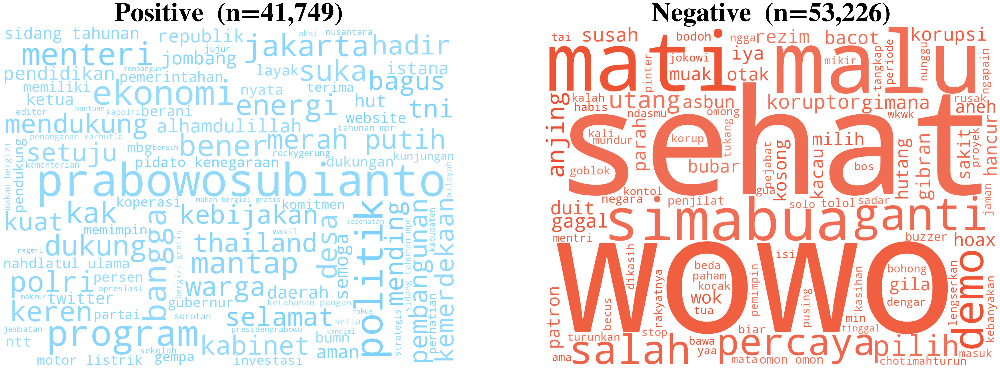

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(8 * len(sent_class), 12))
for ax, s in zip(np.atleast_1d(axes), ['positive','negative']):
    mask = sent == s
    if mask.sum() == 0:
        ax.set_title(f'{s.capitalize()} (no data)'); ax.axis('off'); continue

    wc = WordCloud(width=1600, height=1200, background_color='white',
                   collocations=False, prefer_horizontal=0.9, max_words=100,
                   colormap=ramp(sent_colors[s])
                   ).generate_from_frequencies(distinctive(mask).to_dict())
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{s.capitalize()}  (n={mask.sum():,})', fontsize=36, fontweight='bold')
    ax.axis('off')

## **Topic Space**

In [49]:
docs = df_tm['clean_text'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
).tolist()
timestamps = df_tm['Date'].tolist()  

In [50]:
model_path = hf_hub_download(
    repo_id="Qwen/Qwen2.5-3B-Instruct-GGUF",
    filename="qwen2.5-3b-instruct-q4_k_m.gguf",
)

qwen2.5-3b-instruct-q4_k_m.gguf: reconstructing file:   0%|          |  0.00B / 2.10GB            

qwen2.5-3b-instruct-q4_k_m.gguf: downloading bytes:           |  0.00B            

In [51]:
# Use llama.cpp to load in a Quantized LLM
llm = Llama(model_path=model_path, n_gpu_layers=-1, n_ctx=8192,n_batch=512, stop=["Q:", "\n"],verbose=False)

In [52]:
prompt = """ Q:
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Give a short label of at most 8 words. Output ONLY the label.
Do not explain, do not apologise, do not mention missing context.
If the keywords are unclear, still give your best guess.
A:
"""


representation_model = {
    "LLM": LlamaCPP(llm, prompt=prompt,nr_docs=4,diversity=0.1,doc_length=100,tokenizer='whitespace'),
}

In [53]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedding_model.encode(docs,batch_size=256, show_progress_bar=True)

# Pre-reduce embeddings for visualization purposes
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/529 [00:00<?, ?it/s]

In [ ]:
# Define sub-models
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=290, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [77]:
topic_model = BERTopic(

  # Sub-models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  n_gram_range=(1,3),
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(docs, embeddings)

2026-09-07 09:33:16,456 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-09-07 09:33:18,473 - BERTopic - Dimensionality - Completed ✓
2026-09-07 09:33:18,476 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-07 09:33:22,770 - BERTopic - Cluster - Completed ✓
2026-09-07 09:33:22,796 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 8/8 [00:01<00:00,  6.29it/s]
2026-09-07 09:34:25,068 - BERTopic - Representation - Completed ✓


In [78]:
MAX_WORDS = 13
REFUSAL = re.compile(
    r"not possible|without additional|more information|would be necessary|"
    r"cannot|can't|unable|insufficient|unclear|no clear|as an ai|sorry|"
    r"tidak (dapat|bisa|mungkin|cukup)",
    re.I,
)

def sanitize(raw: str) -> str:
    label = raw.split("\n")[0].strip().strip('"').strip("'")
    label = re.sub(r"^(label|topic|a)\s*[:\-]\s*", "", label, flags=re.I)
    label = re.sub(r"\W+", " ", label).strip()
    if not label or REFUSAL.search(label) or len(label.split()) > MAX_WORDS:
        return "Outlier"
    return label

llm_aspect = topic_model.get_topics(full=True)["LLM"]

label_map = {tid: sanitize(vals[0][0]) for tid, vals in llm_aspect.items()}
label_map[-1] = "Outlier"

topic_model.set_topic_labels(label_map)

In [79]:
all_labels = np.array([label_map[t] for t in topics])
assert len(all_labels) == len(reduced_embeddings), "labels/coords misaligned"

In [80]:
NOISE = "Outlier"
NOISE_ALIASES = ["Outlier", "Unknown Topic"]

all_labels = np.where(np.isin(all_labels, NOISE_ALIASES), NOISE, all_labels)

Calculating medoids: 100%|██████████| 6/6 [00:00<00:00, 140.69it/s]


(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

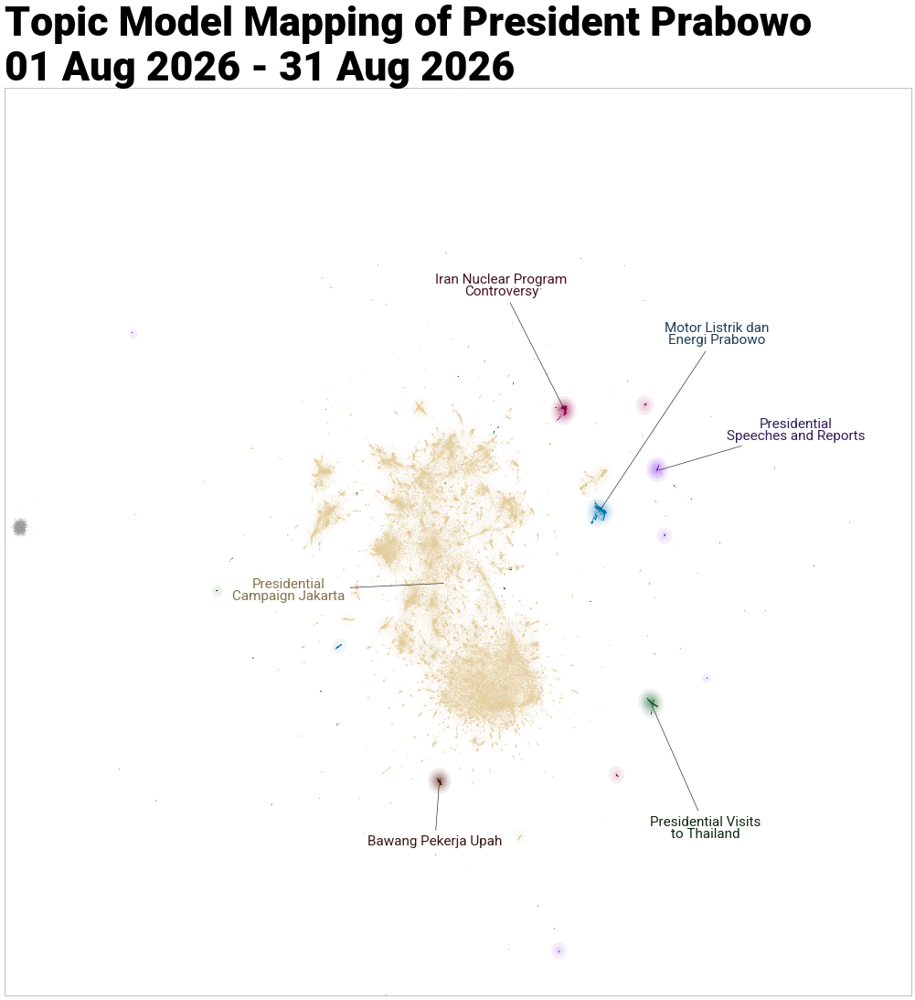

In [81]:
# Run the visualization
datamapplot.create_plot(
    reduced_embeddings,
    all_labels,
    noise_label=NOISE,
    label_font_size=11,
    title=f"Topic Model Mapping of {robj}\n{start_date} - {end_date}",
    label_wrap_width=20,
    use_medoids=True
)

In [ ]:
# same filtered df you fit on

topics_over_time = topic_model.topics_over_time(
    docs,        # the exact list passed to fit_transform
    timestamps,
    nr_bins=20,
)

1it [00:13, 13.30s/it]

In [ ]:
fig = topic_model.visualize_topics_over_time(
    topics_over_time, top_n_topics=10, custom_labels=True
)
fig.show()